In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error



In [3]:
df = pd.read_excel(r"C:\Users\ARJUN\OneDrive\Desktop\printing-internship\real job dataset ( pakka wala ).xlsx")
df.head()


,Press ID,Job Number,Paper type,Zone number,Color,Ink key zero setting,Delta E before,Delta E after,initial density,final density,initial ink key setting,final ink key setting
0,1,1 (24A ),Coated,1.0,Cyan,0mm,5.0,2.15,0.00,0.00,0.00,0.00
1,1,1,Coated,2.0,Cyan,0mm,5.0,2.15,0.00,0.00,0.00,0.00
2,1,1,Coated,3.0,Cyan,0mm,5.0,2.15,1.13,1.25,24.86,27.50
3,1,1,Coated,4.0,Cyan,0mm,5.0,2.15,1.14,1.25,25.08,27.50
4,1,1,Coated,5.0,Cyan,0mm,5.0,2.15,1.14,1.28,25.08,28.16


In [4]:
# normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace("%", "pct", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(" ", "_")
)

print(df.columns.tolist())
df.head()

['Press_ID', 'Job_Number', 'Paper_type', 'Zone_number', 'Color', 'Ink_key_zero_setting', 'Delta_E_before', 'Delta_E_after', 'initial_density', 'final_density', 'initial_ink_key_setting', 'final_ink_key_setting']


,Press_ID,Job_Number,Paper_type,Zone_number,Color,Ink_key_zero_setting,Delta_E_before,Delta_E_after,initial_density,final_density,initial_ink_key_setting,final_ink_key_setting
0,1,1 (24A ),Coated,1.0,Cyan,0mm,5.0,2.15,0.00,0.00,0.00,0.00
1,1,1,Coated,2.0,Cyan,0mm,5.0,2.15,0.00,0.00,0.00,0.00
2,1,1,Coated,3.0,Cyan,0mm,5.0,2.15,1.13,1.25,24.86,27.50
3,1,1,Coated,4.0,Cyan,0mm,5.0,2.15,1.14,1.25,25.08,27.50
4,1,1,Coated,5.0,Cyan,0mm,5.0,2.15,1.14,1.28,25.08,28.16


In [5]:
if "Ink_key_zero_setting" in df.columns:
    df["Ink_key_zero_setting"] = (
        df["Ink_key_zero_setting"]
        .astype(str)
        .str.replace("mm", "", regex=False)
    )
    df["Ink_key_zero_setting"] = pd.to_numeric(df["Ink_key_zero_setting"], errors="coerce")


In [6]:
# convert possible numeric columns safely
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

# force categorical columns to string
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Press_ID                 881 non-null    int64  
 1   Job_Number               881 non-null    object 
 2   Paper_type               881 non-null    object 
 3   Zone_number              880 non-null    float64
 4   Color                    881 non-null    object 
 5   Ink_key_zero_setting     880 non-null    float64
 6   Delta_E_before           880 non-null    float64
 7   Delta_E_after            880 non-null    float64
 8   initial_density          880 non-null    float64
 9   final_density            880 non-null    float64
 10  initial_ink_key_setting  880 non-null    float64
 11  final_ink_key_setting    880 non-null    float64
dtypes: float64(8), int64(1), object(3)
memory usage: 82.7+ KB


C:\Users\ARJUN\AppData\Local\Temp\ipykernel_28384\2183578330.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [7]:
if "Delta_E_before" in df.columns and "Delta_E_after" in df.columns:
    df["DeltaE_reduction"] = df["Delta_E_before"] - df["Delta_E_after"]


In [8]:
for col in df.columns:
    if df[col].nunique() <= 1:
        df = df.drop(columns=[col])


In [9]:
df = df.dropna()
df.shape


(880, 12)

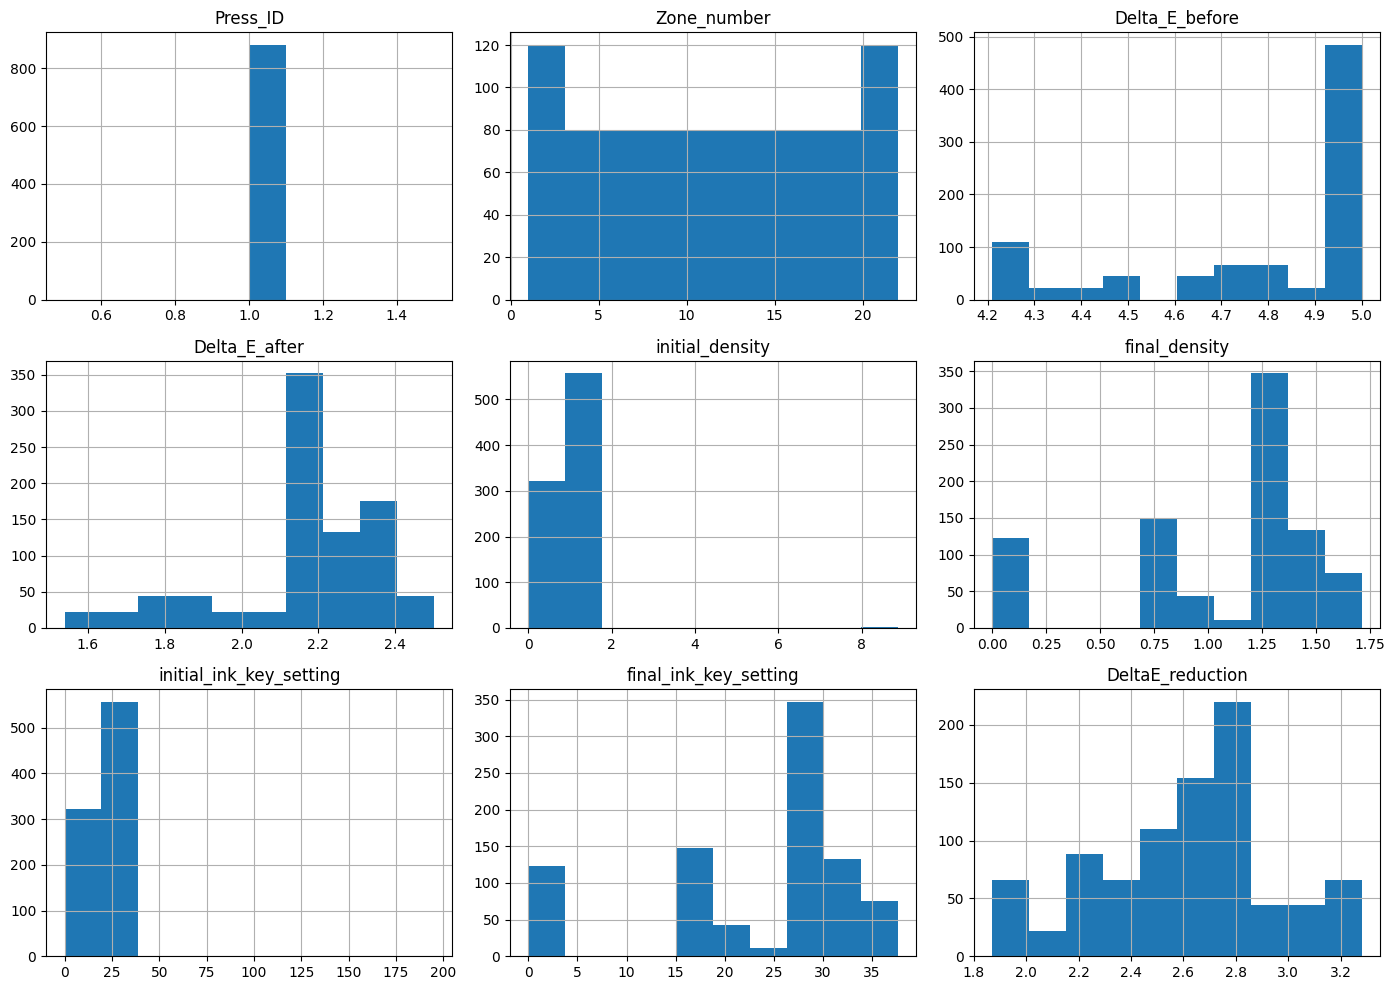

In [10]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()



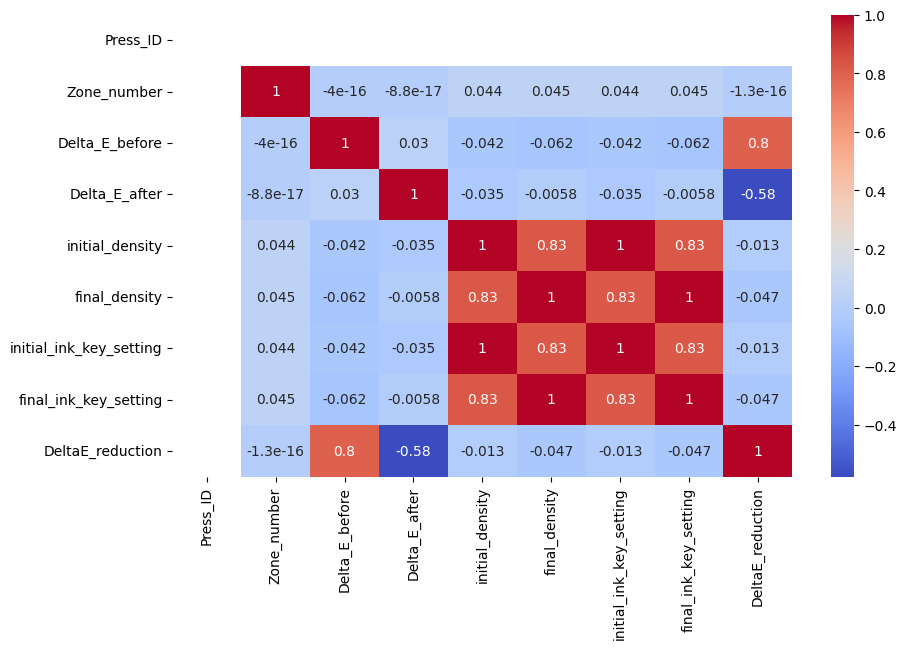

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.show()


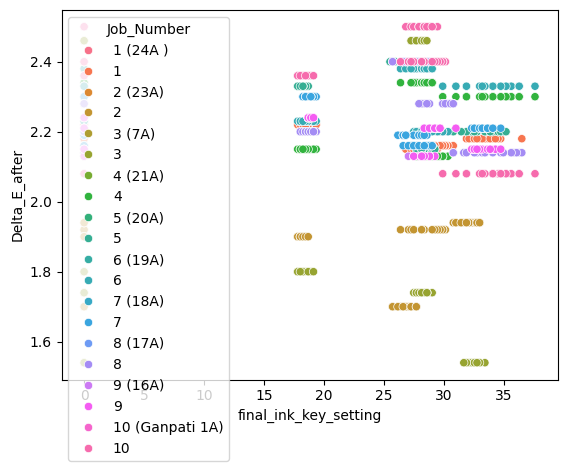

In [12]:
if "final_ink_key_setting" in df.columns and "Delta_E_after" in df.columns:
    sns.scatterplot(data=df, x="final_ink_key_setting", y="Delta_E_after", hue=df.select_dtypes(include="object").columns[0])
    plt.show()


In [13]:
target = "Delta_E_after"

X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)



Numeric: ['Press_ID', 'Zone_number', 'Delta_E_before', 'initial_density', 'final_density', 'initial_ink_key_setting', 'final_ink_key_setting', 'DeltaE_reduction']
Categorical: ['Job_Number', 'Paper_type', 'Color']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)



In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append((name, r2, rmse))

pd.DataFrame(results, columns=["Model", "R2", "RMSE"]).sort_values("R2", ascending=False)


,Model,R2,RMSE
1,RandomForest,0.999955,0.001190
0,Ridge,0.999881,0.001930
2,GradientBoosting,0.999386,0.004376


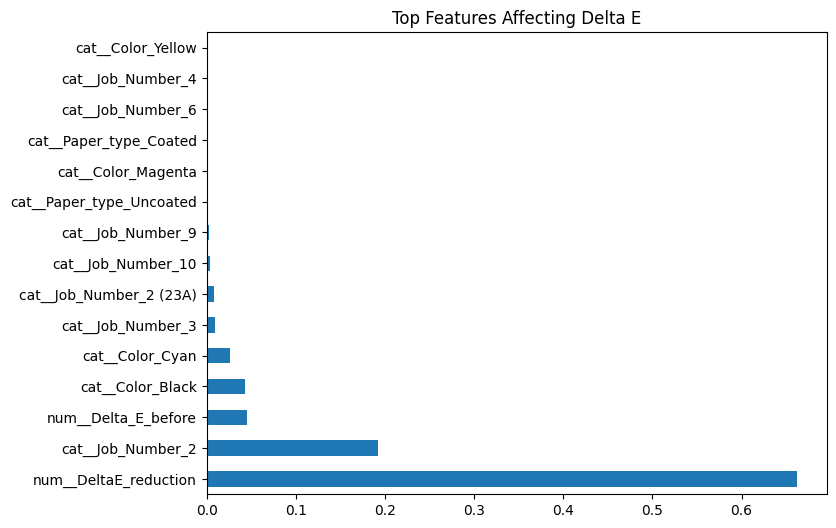

In [17]:
best_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

best_pipe.fit(X_train, y_train)

model = best_pipe.named_steps["model"]
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8,6))
plt.title("Top Features Affecting Delta E")
plt.show()


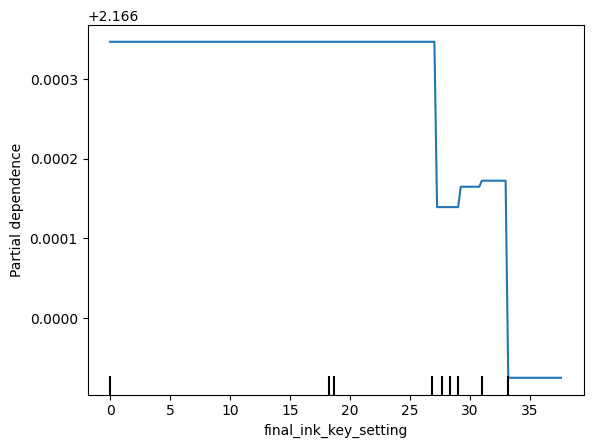

In [18]:
from sklearn.inspection import PartialDependenceDisplay

if "final_ink_key_setting" in X.columns:
    PartialDependenceDisplay.from_estimator(
        best_pipe,
        X_train,
        ["final_ink_key_setting"]
    )
    plt.show()


In [19]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 2.9/101.7 MB 8.0 MB/s eta 0:00:13
   - -------------------------------------- 4.5/101.7 MB 7.7 MB/s eta 0:00:13
   -- ------------------------------------- 5.5/101.7 MB 7.1 MB/s eta 0:00:14
   -- ------------------------------------- 7.1/101.7 MB 7.3 MB/s eta 0:00:14
   --- ------------------------------------ 8.1/101.7 MB 7.1 MB/s eta 0:00:14
   --- ------------------------------------ 8.9/101.7 MB 6.4 MB/s eta 0:00:15
   --- ------------------------------------ 9.7/101.7 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 10.7/101.7 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 11.8/101.7 MB 5.7 MB/s eta 0:00:16
   ---- ----------------------------------- 12.6/101.7 MB 5.6 MB/s et

In [20]:
from xgboost import XGBRegressor


In [21]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)


In [22]:
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])


In [23]:
xgb_pipe.fit(X_train, y_train)


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
xgb_preds = xgb_pipe.predict(X_test)

r2 = r2_score(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost R2:", r2)
print("XGBoost RMSE:", rmse)


XGBoost R2: 0.9995443438086122
XGBoost RMSE: 0.003771090035050702


In [25]:
results.append(("XGBoost", r2, rmse))
pd.DataFrame(results, columns=["Model", "R2", "RMSE"]).sort_values("R2", ascending=False)


,Model,R2,RMSE
1,RandomForest,0.999955,0.001190
0,Ridge,0.999881,0.001930
3,XGBoost,0.999544,0.003771
2,GradientBoosting,0.999386,0.004376


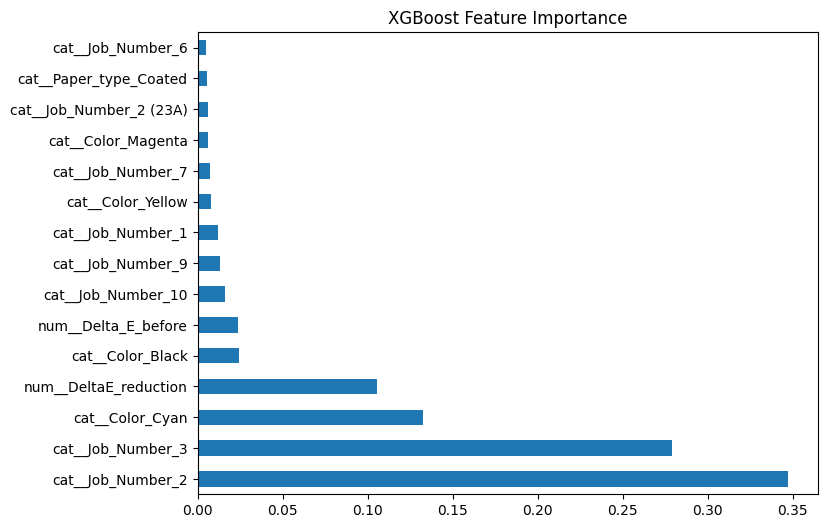

In [26]:
model = xgb_pipe.named_steps["model"]
feature_names = xgb_pipe.named_steps["prep"].get_feature_names_out()

importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8,6))
plt.title("XGBoost Feature Importance")
plt.show()


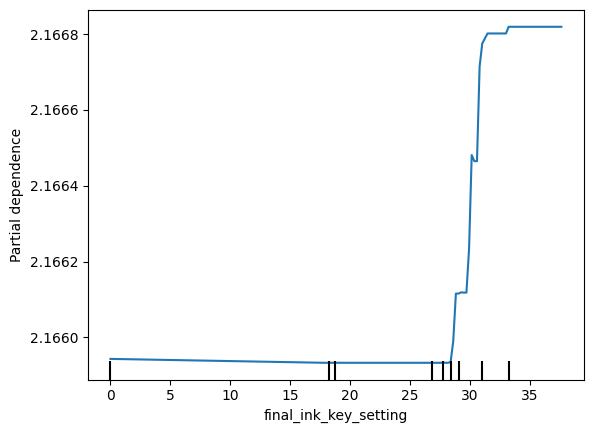

In [27]:
from sklearn.inspection import PartialDependenceDisplay

if "final_ink_key_setting" in X.columns:
    PartialDependenceDisplay.from_estimator(
        xgb_pipe,
        X_train,
        ["final_ink_key_setting"]
    )
    plt.show()


In [28]:
feature_cols = xgb_pipe.named_steps["prep"].feature_names_in_
print(feature_cols)



['Press_ID' 'Job_Number' 'Paper_type' 'Zone_number' 'Color'
 'Delta_E_before' 'initial_density' 'final_density'
 'initial_ink_key_setting' 'final_ink_key_setting' 'DeltaE_reduction']


In [29]:
new_data = pd.DataFrame({
    "Job_Number": [101, 102],
    "Press_ID": [1, 1],
    "Paper_type": ["Uncoated", "Coated"],
    "Color": ["Cyan", "Magenta"],
    "Zone_number": [5, 12],
    "Ink_key_zero_setting": [0, 0],
    "Delta_E_before": [18.5, 15.2],
    "DeltaE_reduction": [10, 9],  # put a placeholder value
    "initial_density": [1.20, 1.10],
    "final_density": [0.95, 0.90],
    "initial_ink_key_setting": [85, 78],
    "final_ink_key_setting": [72, 65],
    "Ink_Key_Difference_pct": [13, 13]
})


In [30]:
# Drop non-feature columns explicitly if present
drop_cols = ["Job_Number", "Press_ID", "DeltaE_reduction"]

for col in drop_cols:
    if col in X.columns:
        X = X.drop(columns=[col])

# SAVE FEATURE ORDER
feature_cols = X.columns.tolist()

feature_cols

['Paper_type',
 'Zone_number',
 'Color',
 'Delta_E_before',
 'initial_density',
 'final_density',
 'initial_ink_key_setting',
 'final_ink_key_setting']

In [31]:
new_data = new_data.reindex(columns=feature_cols, fill_value=0)


In [32]:
required_cols = xgb_pipe.named_steps["prep"].feature_names_in_
print(required_cols)




['Press_ID' 'Job_Number' 'Paper_type' 'Zone_number' 'Color'
 'Delta_E_before' 'initial_density' 'final_density'
 'initial_ink_key_setting' 'final_ink_key_setting' 'DeltaE_reduction']


In [33]:
new_data = new_data.copy()

# normalize column names same as training
new_data.columns = (
    new_data.columns
    .str.strip()
    .str.replace("%", "pct", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(" ", "_")
)

# ADD missing columns with safe default values
for col in required_cols:
    if col not in new_data.columns:
        if col == "DeltaE_reduction":
            new_data[col] = 0  # placeholder numeric
        elif col in ["Job_Number", "Press_ID"]:
            new_data[col] = 0  # ID placeholder
        else:
            new_data[col] = 0

# ensure correct column order
new_data = new_data[required_cols]


In [34]:
required_cols = xgb_pipe.named_steps["prep"].feature_names_in_

# Get numeric + categorical lists from training
train_num_cols = num_cols
train_cat_cols = cat_cols



In [35]:
new_data.columns = (
    new_data.columns
    .str.strip()
    .str.replace("%", "pct", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(" ", "_")
)


In [36]:
for col in required_cols:
    if col not in new_data.columns:
        new_data[col] = 0


In [37]:
# numeric → numeric
for col in train_num_cols:
    if col in new_data.columns:
        new_data[col] = pd.to_numeric(new_data[col], errors="coerce")

# categorical → string
for col in train_cat_cols:
    if col in new_data.columns:
        new_data[col] = new_data[col].astype(str)


In [38]:
new_data = new_data[required_cols]


In [39]:
new_data = new_data.fillna(0)


In [40]:
predictions = xgb_pipe.predict(new_data)

new_data["Predicted_Delta_E_after"] = predictions
new_data


,Press_ID,Job_Number,Paper_type,Zone_number,Color,Delta_E_before,initial_density,final_density,initial_ink_key_setting,final_ink_key_setting,DeltaE_reduction,Predicted_Delta_E_after
0,0,0,Uncoated,5,Cyan,18.5,1.2,0.95,85,72,0,2.457413
1,0,0,Coated,12,Magenta,15.2,1.1,0.90,78,65,0,2.375309


In [41]:
import joblib

# This saves the entire pipeline (including the Scaler and Encoder)
joblib.dump(xgb_pipe, 'ink_model_pipeline.pkl')
print("Model saved successfully!")

Model saved successfully!
